In [1]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np
import cv2
from torch.utils.data import Dataset


In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:

class RedShapesDataset(Dataset):
    def __init__(self, n_samples=1000, img_size=64):
        self.n_samples = n_samples
        self.img_size = img_size

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img = np.ones((self.img_size, self.img_size, 3), dtype=np.uint8) * 255
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        # Keep list of all shapes to draw in order
        shapes = []
        for _ in range(np.random.randint(1, 5)):
            color = np.random.choice(['red', 'green', 'blue'])
            center = np.random.randint(10, self.img_size-10, 2)
            radius = np.random.randint(5, 15)
            shapes.append((color, tuple(center), radius))
        # Draw in order, last shape drawn is on top (like real painting)
        for color, center, radius in shapes:
            if color == 'red':
                cv2.circle(img, center, radius, (0,0,255), -1)  # Red in BGR
            elif color == 'green':
                cv2.circle(img, center, radius, (0,255,0), -1)
            else:
                cv2.circle(img, center, radius, (255,0,0), -1)
        # Build mask from final (visible) red
        red_pixels = (img[:,:,0] > 150) & (img[:,:,1] < 80) & (img[:,:,2] < 80)
        mask[red_pixels] = 1
        mask = mask.astype(np.float32)[None, ...]
        img = img.astype(np.float32)/255.0
        img = np.transpose(img, (2,0,1))
        return img, mask




In [4]:
dataset = RedShapesDataset()


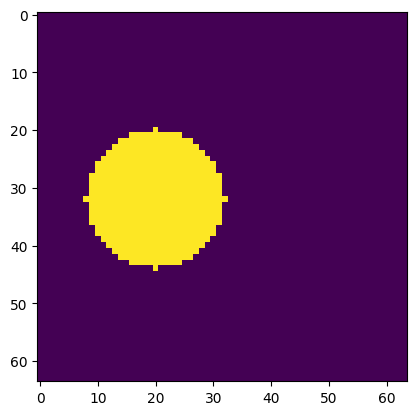

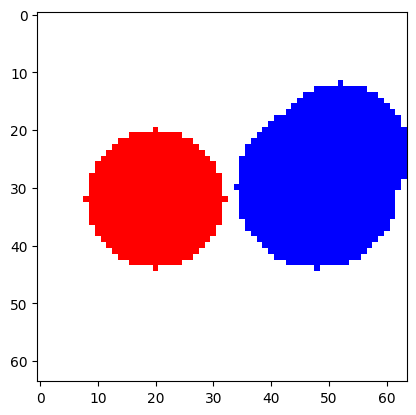

In [5]:
item = dataset.__getitem__(1)
plt.imshow(item[1].T)
plt.show()
plt.imshow(item[0].T)
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FilterEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(FilterEncoder, self).__init__()
        # Encoder: (B, 3, 64, 64) → (B, 64, 16, 16)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # → (B,32,32,32)
            nn.ELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → (B,64,16,16)
            nn.ELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # → (B,128,8,8)
            nn.ELU(),
            nn.Flatten()
        )
        # Flatten and project down
        self.fc_enc = nn.Linear(128*8*8, latent_dim)
        # Decoder: project up and unflatten
        self.fc_dec = nn.Linear(latent_dim, 128*8*8)
        self.unflatten = nn.Unflatten(1, (128,8,8))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # (B,64,16,16)
            nn.ELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (B,32,32,32)
            nn.ELU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # (B,1,64,64)
            nn.Sigmoid()   # values in [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.fc_enc(x)
        x = self.fc_dec(x)
        x = self.unflatten(x)
        x = self.decoder(x)
        return x


In [ ]:
# bce = torch.nn.BCEWithLogitsLoss()
# def dice_loss(pred, target, smooth=1.):
#     # pred: output logits, need to apply sigmoid first
#     pred = torch.sigmoid(pred)
#     # Flatten
#     pred = pred.view(-1)
#     target = target.view(-1)
#     intersection = (pred * target).sum()
#     dice = 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
#     bce_loss = bce(pred, target)

#     return dice + bce_loss


In [59]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

dataset = RedShapesDataset(500, img_size=64)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
model = FilterEncoder(32)
# model.load_state_dict(torch.load('best_model.pth'))
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)


In [60]:
min_loss = float('inf')

In [79]:
for epoch in range(20):
    model.train()
    epoch_loss = 0.0

    for imgs, masks in loader:
        imgs = imgs.float()
        masks = masks.float()

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if loss.item() < min_loss:
            min_loss = loss.item()
            torch.save(model.state_dict(), 'best_model.pth')

    scheduler.step(epoch_loss / len(loader))
    print(f"Epoch {epoch}: Loss={epoch_loss / len(loader):.4f} LR={scheduler.get_last_lr()[0]}")

Epoch 0: Loss=0.0250 LR=0.001
Epoch 1: Loss=0.0235 LR=0.001
Epoch 2: Loss=0.0226 LR=0.001
Epoch 3: Loss=0.0262 LR=0.001
Epoch 4: Loss=0.0243 LR=0.001
Epoch 5: Loss=0.0268 LR=0.001
Epoch 6: Loss=0.0242 LR=0.001
Epoch 7: Loss=0.0238 LR=0.001
Epoch 8: Loss=0.0217 LR=0.001
Epoch 9: Loss=0.0201 LR=0.001
Epoch 10: Loss=0.0235 LR=0.001
Epoch 11: Loss=0.0227 LR=0.001
Epoch 12: Loss=0.0212 LR=0.001
Epoch 13: Loss=0.0208 LR=0.001
Epoch 14: Loss=0.0205 LR=0.001
Epoch 15: Loss=0.0192 LR=0.001
Epoch 16: Loss=0.0197 LR=0.001
Epoch 17: Loss=0.0209 LR=0.001
Epoch 18: Loss=0.0217 LR=0.001
Epoch 19: Loss=0.0220 LR=0.001


In [80]:
best_model = FilterEncoder(latent_dim=32)
best_model.load_state_dict(torch.load('best_model.pth'))


<All keys matched successfully>

[W509 13:34:22.062628974 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.068081424 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.075999963 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.077338023 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.083482953 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.084944834 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.092460670 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.093792324 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.099693824 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W509 13:34:22.116782550 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


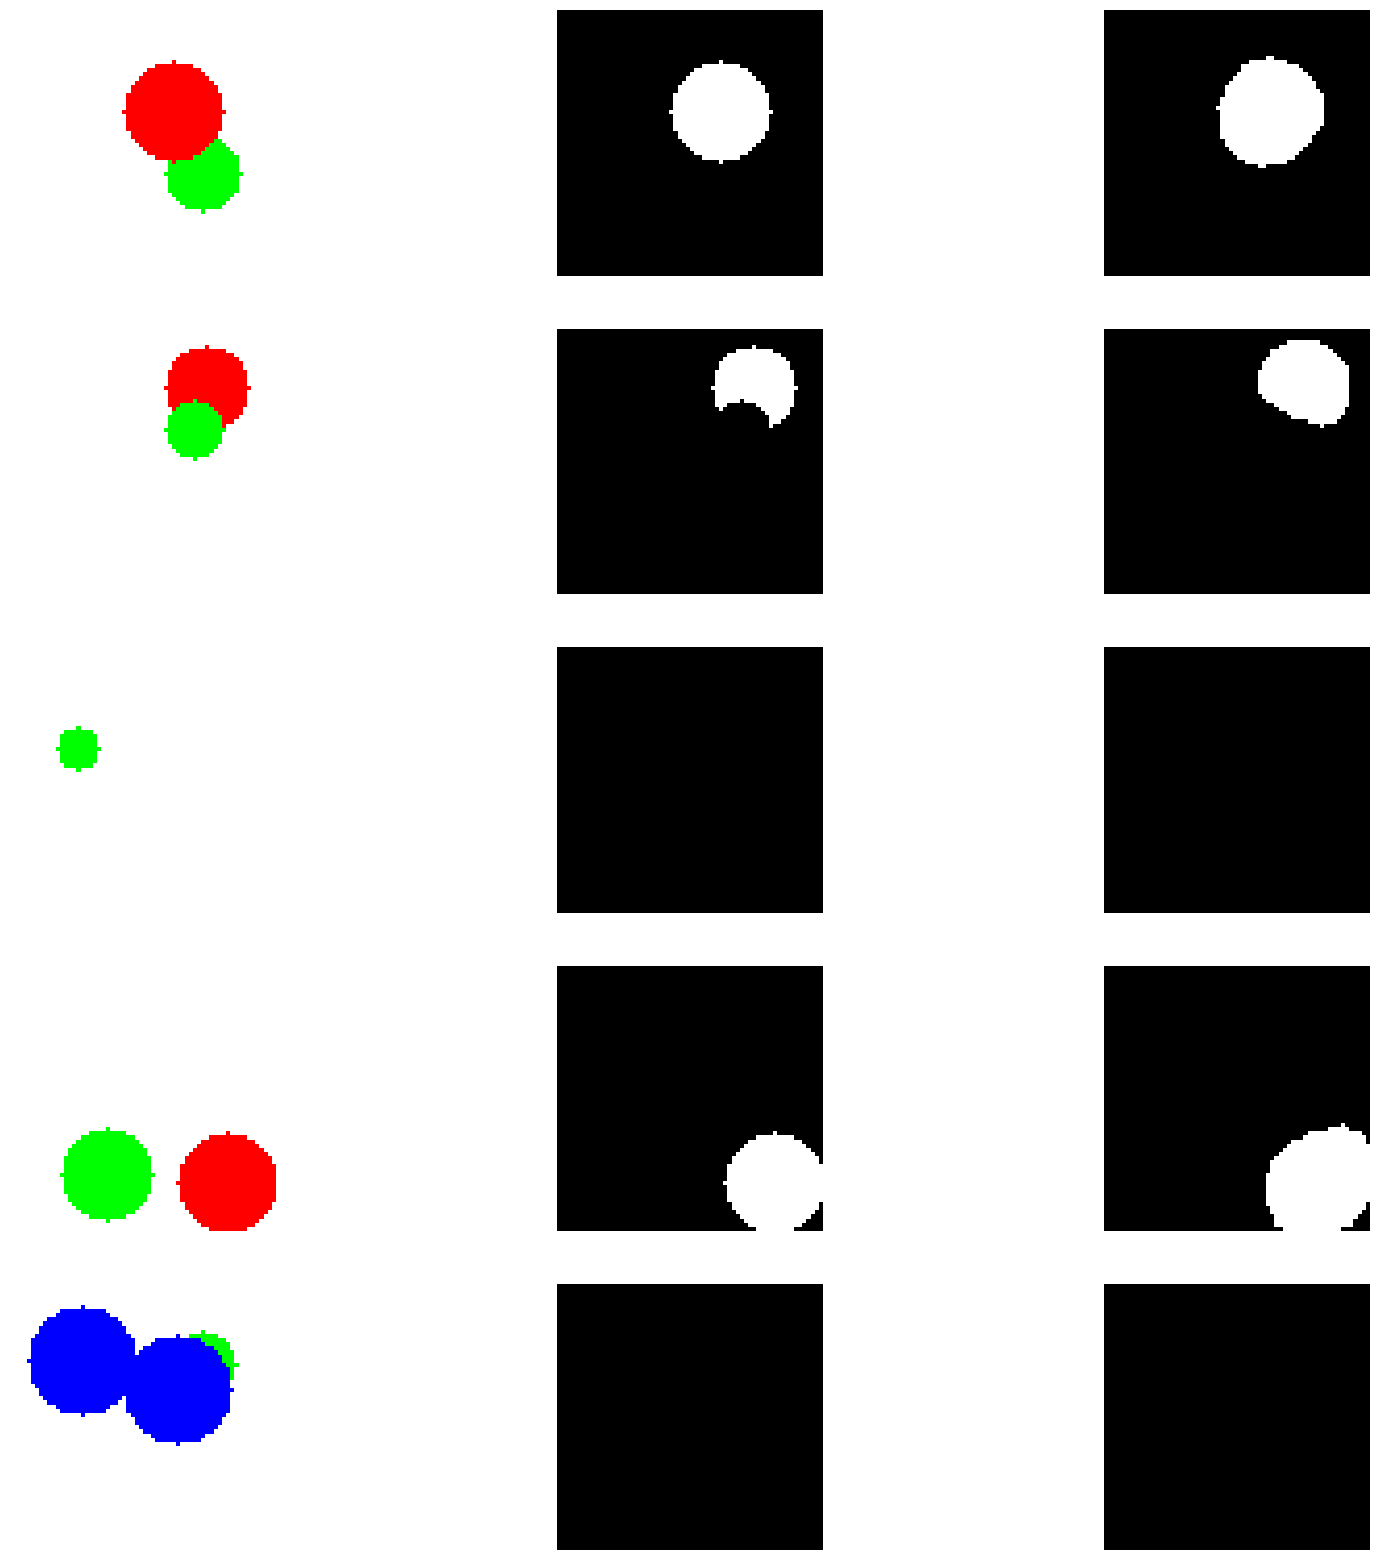

In [81]:
best_model.eval()
with torch.no_grad():
    model_device = next(best_model.parameters()).device
    fig, axes = plt.subplots(5, 3, figsize=(20, 20))

    for i in range(5):
        img_np, mask = dataset[i]
        img_tensor = torch.from_numpy(img_np).unsqueeze(0).to(model_device)

        pred = best_model(img_tensor)
        pred_np = (pred.squeeze(0).squeeze(0).cpu().numpy()>0.5).astype(np.float32)

        img_show = np.transpose(img_np, (1, 2, 0))

        axes[i, 0].imshow(img_show)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].axis('off')

    plt.show()